# Deep Residual Learning — Reproduction Study

> **He et al., "Deep Residual Learning for Image Recognition" (CVPR 2016)**



In [ ]:
import os # interact with system(folders, paths)
import time # to measure training time
import random # generates random numbers
import multiprocessing # parallel CPU workers(used indirectly with dataloader)
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms # preprocessing(normalize, augument)
from torch.utils.data import DataLoader
# AMP = Automatic Mixed Precision -> accelerates training speed and reduces memory usage
from torch.amp import GradScaler, autocast # autocast-> runs ops in lower precision (float16),
                                           # gradscalar-> prevents numerical instability
SEED = 42
random.seed(SEED) # Python's built-in random module
np.random.seed(SEED) # NumPy random
torch.manual_seed(SEED) # PyTorch CPU operations
torch.cuda.manual_seed_all(SEED)  # PyTorch GPU operations
torch.backends.cudnn.deterministic = True # forces CUDA to use the same algorithm every run
torch.backends.cudnn.benchmark = False # stops CUDA from auto-selecting the "fastest" algorithm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

print('Setup done.')

Using device: cuda
Setup done.


In [ ]:
# All four models will be trained with these exact same settings except skip connec. present or not
EPOCHS     = 50
BATCH_SIZE = 256      # 256 images per gradient update
LR         = 0.1
MOMENTUM   = 0.9
WD         = 1e-4
NUM_WORKERS = min(2, multiprocessing.cpu_count())# how many CPU processes load data in parallel

print(f'EPOCHS     = {EPOCHS}')
print(f'BATCH_SIZE = {BATCH_SIZE}')
print(f'LR         = {LR}')
print(f'NUM_WORKERS= {NUM_WORKERS}')

EPOCHS     = 50
BATCH_SIZE = 256
LR         = 0.1
NUM_WORKERS= 2


In [ ]:
# CIFAR-10 per-channel mean and standard deviation (precomputed from the dataset)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)
base_transform = transforms.Compose([ # normalization
    transforms.ToTensor(), # PIL image to tensor, scales to [0,1]
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),  # centers each channel around 0
])
aug_transform = transforms.Compose([ # augumentation
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(), # randomly mirror the image
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
test_transform = transforms.Compose([ # Test transform only normalize
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

def get_loaders(train_transform):
    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=train_transform
    )
    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_transform
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True, # keeps data in page-locked(fixed location in cpu-gpu can access it faster)
        persistent_workers=True   # keeps worker processes alive every epoch which saves time
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True
    )
    return train_loader, test_loader
# Load data (no augmentation)
train_loader, test_loader = get_loaders(base_transform)

print(f'Training samples : {len(train_loader.dataset)}')
print(f'Test samples     : {len(test_loader.dataset)}')
print(f'Batches per epoch: {len(train_loader)}')

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


Training samples : 50000
Test samples     : 10000
Batches per epoch: 196


In [ ]:
    # Structure:  x → Conv → BN → ReLU → Conv → BN → ReLU → output
class PlainBlock(nn.Module): # plain conv block no skip connection.
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels,# First conv: can change spatial size (via stride) and channel count
                               kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels,# Second conv: same channels in and out, no spatial change
                               kernel_size=3, stride=1, padding=1, bias=False) # bias=False because BatchNorm already adds a learnable bias
        self.bn2   = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = torch.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = torch.relu(out)
        return out   # just F(x) — no identity path


# x → Conv → BN → ReLU → Conv → BN(batch normalization) → (+x)[skip connection] → ReLU → output
class ResidualBlock(nn.Module):  # residual block with skip connection (ResNet core idea)
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, # First conv: extracts features, can change spatial size (stride) + channels
                               kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)  # normalize activations → stable training
        self.conv2 = nn.Conv2d(out_channels, out_channels,# Second conv: keeps same spatial size and channels
                               kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        # Shortcut path (skip connection)
        # default: identity (x passes unchanged)
        # but if shape changes (channels/size), we must adjust x before adding
        channels_changed = (in_channels != out_channels)
        size_changed     = (stride != 1)
        if channels_changed or size_changed:
            # 1x1 conv adjusts shape of x → so we can do F(x) + x
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:# no change needed → direct identity mapping
            self.shortcut = nn.Identity()

    def forward(self, x):
        # Main path: compute residual function F(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = torch.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        # Skip path: either identity(x) or transformed x (via 1x1 conv)
        skip = self.shortcut(x)
        # Core ResNet idea → output = F(x) + x
        out = out + skip
        # Final activation after merging both paths
        out = torch.relu(out)
        return out

print('PlainBlock and ResidualBlock defined.')

PlainBlock and ResidualBlock defined.


In [ ]:
class PlainCNN(nn.Module):  # plain CNN without skip connections

    def __init__(self, n_blocks, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(  # initial feature extractor (3 → 16 channels)
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )

        self.stage1 = self._make_stage(16, 16, n_blocks, stride=1)  # keep size
        self.stage2 = self._make_stage(16, 16, n_blocks, stride=2)  # downsample
        self.stage3 = self._make_stage(16, 16, n_blocks, stride=2)  # downsample
        self.pool = nn.AdaptiveAvgPool2d(1)  # spatial → 1×1 per channel
        self.fc = nn.Linear(16, num_classes)  # classifier (16 → classes)

    def _make_stage(self, in_channels, out_channels, n_blocks, stride):
        blocks = [PlainBlock(in_channels, out_channels, stride=stride)]  # first block may downsample
        for _ in range(n_blocks - 1):
            blocks.append(PlainBlock(out_channels, out_channels, stride=1))  # rest keep shape
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = self.stem(x)     # [B,3,32,32] → [B,16,32,32]
        x = self.stage1(x)   # no size change
        x = self.stage2(x)   # spatial ↓ (32→16)
        x = self.stage3(x)   # spatial ↓ (16→8)
        x = self.pool(x)     # [B,16,8,8] → [B,16,1,1]
        x = x.flatten(1)     # flatten to vector
        x = self.fc(x)       # logits output
        return x


class ResNet(nn.Module):  # residual network with skip connections

    def __init__(self, n_blocks, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(  # same initial feature extractor
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )
        self.stage1 = self._make_stage(16, 16, n_blocks, stride=1)  # same channels
        self.stage2 = self._make_stage(16, 32, n_blocks, stride=2)  # increase channels + downsample
        self.stage3 = self._make_stage(32, 64, n_blocks, stride=2)  # increase channels + downsample
        self.pool = nn.AdaptiveAvgPool2d(1)  # global pooling
        self.fc   = nn.Linear(64, num_classes)  # final classifier (64 → classes)

    def _make_stage(self, in_channels, out_channels, n_blocks, stride):
        blocks = [ResidualBlock(in_channels, out_channels, stride=stride)]  # first handles shape change
        for _ in range(n_blocks - 1):
            blocks.append(ResidualBlock(out_channels, out_channels, stride=1))  # rest same shape
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = self.stem(x)     # [B,3,32,32] → [B,16,32,32]
        x = self.stage1(x)   # no change
        x = self.stage2(x)   # channels ↑, size ↓
        x = self.stage3(x)   # channels ↑, size ↓
        x = self.pool(x)     # [B,64,8,8] → [B,64,1,1]
        x = x.flatten(1)     # flatten
        x = self.fc(x)       # logits
        return x

def count_params(model):  # count trainable parameters
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Model parameter counts:')
print(f'  CNN-20    : {count_params(PlainCNN(n_blocks=3)):>8,}')   # shallow plain CNN
print(f'  CNN-56    : {count_params(PlainCNN(n_blocks=9)):>8,}')   # deeper plain CNN
print(f'  ResNet-20 : {count_params(ResNet(n_blocks=3)):>8,}')     # shallow ResNet
print(f'  ResNet-32 : {count_params(ResNet(n_blocks=5)):>8,}')     # deeper ResNet
print()
print('Note: ResNet has more parameters than CNN — capacity is not the limiting factor')  # key claim
print('CNN-56 worse than CNN-20 despite more params → degradation is optimization, not capacity')  # core insight

Model parameter counts:
  CNN-20    :   42,682
  CNN-56    :  126,778
  ResNet-20 :  272,474
  ResNet-32 :  466,906

Note: ResNet has more parameters than CNN — this is a known limitation.
The degradation result (CNN-56 worse than CNN-20 despite MORE params)
cannot be explained by capacity. That result stands on its own.


In [ ]:
def train_one_model(model, train_loader, test_loader, use_scheduler=False):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=LR,
        momentum=MOMENTUM,
        weight_decay=WD  # L2 regularization → controls weight growth
    )
    if use_scheduler:
        scheduler = optim.lr_scheduler.MultiStepLR(
            optimizer, milestones=[25, 40], gamma=0.1  # step LR decay
        )
    else:
        scheduler = None
    scaler = GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))  # AMP for speed + stability
    history = {'train_loss': [], 'test_acc': []}
    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()
        model.train()
        total_loss = 0.0

        for images, labels in train_loader:
            images = images.to(DEVICE, non_blocking=True)  # async CPU→GPU transfer
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)  # faster than zeroing grads
            with autocast('cuda', enabled=(DEVICE.type == 'cuda')):  # mixed precision forward
                predictions = model(images)
                loss = criterion(predictions, labels)
            scaler.scale(loss).backward()  # scaled backprop avoids FP16 underflow
            scaler.step(optimizer)  # unscales + updates weights
            scaler.update()         # adapts scaling factor
            total_loss += loss.item() * images.size(0)  # un-averaged accumulation

        if scheduler:
            scheduler.step()
        avg_loss = total_loss / len(train_loader.dataset)
        acc      = evaluate(model, test_loader)  # test set evaluation each epoch
        elapsed  = time.time() - epoch_start
        history['train_loss'].append(avg_loss)
        history['test_acc'].append(acc)
        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | Acc: {acc:.1f}% | {elapsed:.1f}s')
    return history

def evaluate(model, loader):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():  # disable grads → faster + less memory
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            outputs = model(images)
            preds   = outputs.argmax(1)  # pick highest logit
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return 100.0 * correct / total

Training loop defined.


In [ ]:
print('Phase 1 — Baseline Training (no augmentation, no LR schedule)')
print('=' * 60)
results_p1 = {}  # stores per-model training curves
epoch_times = {}  # track compute cost (sec/epoch)
models_to_train = {  # fresh models → fair comparison (no weight reuse)
    'CNN-20':    PlainCNN(n_blocks=3),
    'CNN-56':    PlainCNN(n_blocks=9),
    'ResNet-20': ResNet(n_blocks=3),
    'ResNet-32': ResNet(n_blocks=5),
}

for name, model in models_to_train.items():
    print(f'\nTraining {name}  ({count_params(model):,} params)')
    print('-' * 40)
    t_start = time.time()
    results_p1[name] = train_one_model(model, train_loader, test_loader)  # identical training setup
    t_total = time.time() - t_start
    epoch_times[name] = t_total / EPOCHS  # normalize time → comparable across models
    filename = name.replace('-', '').lower() + '_p1.pt'
    torch.save(model.state_dict(), f'results/{filename}')  # save for later analysis

print('\nPhase 1 complete.')

Phase 1 — Baseline Training (no augmentation, no LR schedule)

Training CNN-20  (42,682 params)
----------------------------------------
  Epoch   1/50 | Loss: 1.8300 | Acc: 28.2% | 19.7s
  Epoch  10/50 | Loss: 0.7206 | Acc: 69.9% | 15.2s
  Epoch  20/50 | Loss: 0.5329 | Acc: 73.4% | 15.4s
  Epoch  30/50 | Loss: 0.4558 | Acc: 69.7% | 14.9s
  Epoch  40/50 | Loss: 0.4032 | Acc: 73.8% | 16.1s
  Epoch  50/50 | Loss: 0.3601 | Acc: 73.6% | 14.5s

Training CNN-56  (126,778 params)
----------------------------------------
  Epoch   1/50 | Loss: 2.2898 | Acc: 14.4% | 19.4s
  Epoch  10/50 | Loss: 1.5836 | Acc: 38.2% | 20.8s
  Epoch  20/50 | Loss: 1.3194 | Acc: 46.5% | 19.7s
  Epoch  30/50 | Loss: 1.1323 | Acc: 55.3% | 19.5s
  Epoch  40/50 | Loss: 0.9733 | Acc: 58.1% | 20.0s
  Epoch  50/50 | Loss: 0.8456 | Acc: 53.2% | 19.8s

Training ResNet-20  (272,474 params)
----------------------------------------
  Epoch   1/50 | Loss: 1.6248 | Acc: 42.0% | 15.1s
  Epoch  10/50 | Loss: 0.3147 | Acc: 77.8% | 

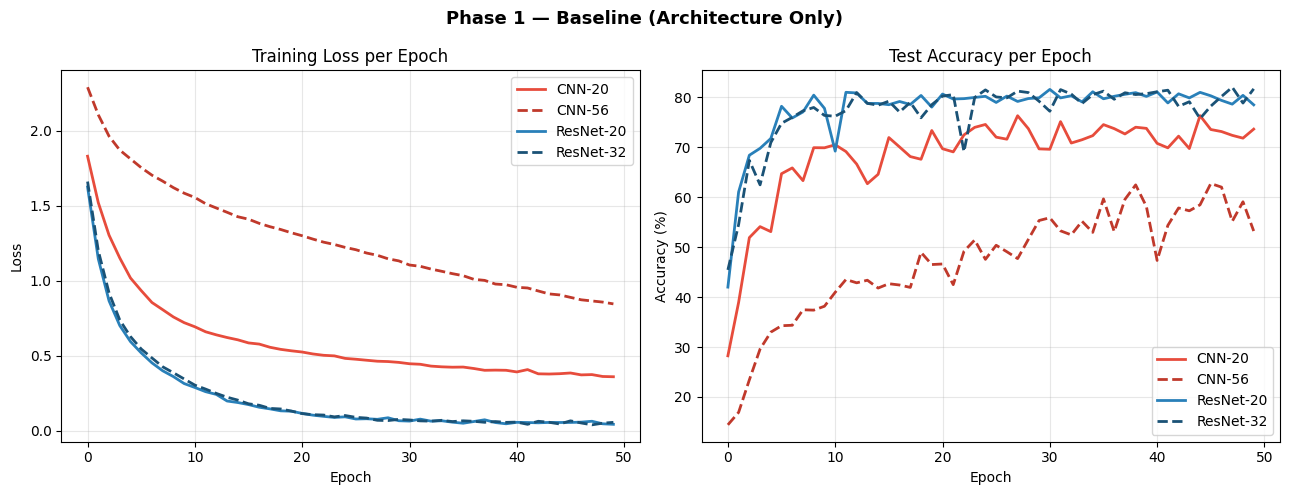

Saved → results/phase1_curves.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Phase 1 — Baseline (Architecture Only)', fontsize=13, fontweight='bold')
COLORS = {  # consistent color mapping across plots
    'CNN-20': '#e74c3c', 'CNN-56': '#c0392b',
    'ResNet-20': '#2980b9', 'ResNet-32': '#1a5276'
}
LINESTYLES = {  # dashed = deeper variant
    'CNN-20': '-', 'CNN-56': '--',
    'ResNet-20': '-', 'ResNet-32': '--'
}

for name, hist in results_p1.items():
    ax1.plot(hist['train_loss'], label=name,
             color=COLORS[name], linestyle=LINESTYLES[name], linewidth=2)
    ax2.plot(hist['test_acc'], label=name,
             color=COLORS[name], linestyle=LINESTYLES[name], linewidth=2)
ax1.set_title('Training Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)
ax2.set_title('Test Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/phase1_curves.png', dpi=150, bbox_inches='tight')  # persist for report
plt.show()

print('Saved → results/phase1_curves.png')

In [ ]:
# Final accuracy = last epoch test accuracy
acc_p1 = {name: hist['test_acc'][-1] for name, hist in results_p1.items()}
print('Phase 1 — Final Test Accuracy')
print('-' * 42)
print(f"{'Model':<12}  {'Params':>8}  {'Accuracy':>9}")
print('-' * 42)
param_counts = {  # parameter count per model (capacity reference)
    'CNN-20':    count_params(PlainCNN(n_blocks=3)),
    'CNN-56':    count_params(PlainCNN(n_blocks=9)),
    'ResNet-20': count_params(ResNet(n_blocks=3)),
    'ResNet-32': count_params(ResNet(n_blocks=5)),
}

for name in ['CNN-20', 'CNN-56', 'ResNet-20', 'ResNet-32']:
    print(f"  {name:<10}  {param_counts[name]:>8,}  {acc_p1[name]:>8.2f}%")
print('-' * 42)
cnn_gap    = acc_p1['CNN-56']    - acc_p1['CNN-20']     # degradation signal (should be negative)
resnet_gap = acc_p1['ResNet-32'] - acc_p1['ResNet-20']  # depth benefit (should be positive)

print()
print('Degradation check:')
print(f'  CNN-56 vs CNN-20    : {cnn_gap:+.2f}%', end='  ')
print('← DEGRADATION CONFIRMED' if cnn_gap < 0 else '← degradation not observed')
print(f'  ResNet-32 vs ResNet-20: {resnet_gap:+.2f}%', end='  ')
print('← DEPTH HELPS' if resnet_gap > 0 else '← depth not helping')

Phase 1 — Final Test Accuracy
------------------------------------------
Model           Params   Accuracy
------------------------------------------
  CNN-20        42,682     73.64%
  CNN-56       126,778     53.23%
  ResNet-20    272,474     78.50%
  ResNet-32    466,906     81.70%
------------------------------------------

Degradation check:
  CNN-56 vs CNN-20    : -20.41%  ← DEGRADATION CONFIRMED
  ResNet-32 vs ResNet-20: +3.20%  ← DEPTH HELPS


In [ ]:
print('Phase 2 — With Augmentation + LR Scheduling')
print('=' * 60)
train_loader_aug, test_loader_aug = get_loaders(aug_transform)  # harder training distribution
results_p2 = {}
models_phase2 = {  # fresh models → no carryover from Phase 1
    'CNN-20':    PlainCNN(n_blocks=3),
    'CNN-56':    PlainCNN(n_blocks=9),
    'ResNet-20': ResNet(n_blocks=3),
    'ResNet-32': ResNet(n_blocks=5),
}

for name, model in models_phase2.items():
    print(f'\nTraining {name}')
    print('-' * 40)
    results_p2[name] = train_one_model(
        model, train_loader_aug, test_loader_aug,
        use_scheduler=True  # stronger optimization setup
    )
    filename = name.replace('-', '').lower() + '_p2.pt'
    torch.save(model.state_dict(), f'results/{filename}')  # save improved models

print('\nPhase 2 complete.')

Phase 2 — With Augmentation + LR Scheduling

Training CNN-20
----------------------------------------
  Epoch   1/50 | Loss: 1.8640 | Acc: 35.3% | 19.8s
  Epoch  10/50 | Loss: 0.8697 | Acc: 63.7% | 19.7s
  Epoch  20/50 | Loss: 0.6667 | Acc: 72.5% | 20.2s
  Epoch  30/50 | Loss: 0.4866 | Acc: 81.5% | 21.0s
  Epoch  40/50 | Loss: 0.4630 | Acc: 81.0% | 19.5s
  Epoch  50/50 | Loss: 0.4396 | Acc: 82.1% | 21.0s

Training CNN-56
----------------------------------------
  Epoch   1/50 | Loss: 2.2558 | Acc: 10.0% | 24.0s
  Epoch  10/50 | Loss: 1.7300 | Acc: 35.5% | 24.5s
  Epoch  20/50 | Loss: 1.5429 | Acc: 44.6% | 23.9s
  Epoch  30/50 | Loss: 1.2736 | Acc: 55.1% | 24.1s
  Epoch  40/50 | Loss: 1.2135 | Acc: 57.3% | 24.6s
  Epoch  50/50 | Loss: 1.1767 | Acc: 58.9% | 24.3s

Training ResNet-20
----------------------------------------
  Epoch   1/50 | Loss: 1.6799 | Acc: 41.9% | 20.4s
  Epoch  10/50 | Loss: 0.4835 | Acc: 76.3% | 20.5s
  Epoch  20/50 | Loss: 0.3408 | Acc: 82.4% | 20.4s
  Epoch  30/50

In [ ]:
# Phase 2 final accuracy
acc_p2 = {name: hist['test_acc'][-1] for name, hist in results_p2.items()}
print('Phase 1 vs Phase 2 — Accuracy Comparison')
print('-' * 52)
print(f"{'Model':<12}  {'Phase 1':>9}  {'Phase 2':>9}  {'Delta':>7}")
print('-' * 52)

for name in ['CNN-20', 'CNN-56', 'ResNet-20', 'ResNet-32']:
    a1    = acc_p1[name]
    a2    = acc_p2[name]
    delta = a2 - a1  # improvement from better training
    print(f"  {name:<10}  {a1:>8.2f}%  {a2:>8.2f}%  {delta:>+6.2f}%")
print('-' * 52)
cnn_gap_p2 = acc_p2['CNN-56'] - acc_p2['CNN-20']  # post-improvement degradation signal

print()
print(f'CNN-56 still lags CNN-20 after improvements: {cnn_gap_p2:+.2f}%', end='  ')
print('← degradation persists' if cnn_gap_p2 < 0 else '← gap closed by training tricks')

Phase 1 vs Phase 2 — Accuracy Comparison
----------------------------------------------------
Model           Phase 1    Phase 2    Delta
----------------------------------------------------
  CNN-20         73.64%     82.06%   +8.42%
  CNN-56         53.23%     58.94%   +5.71%
  ResNet-20      78.50%     89.33%  +10.83%
  ResNet-32      81.70%     90.01%   +8.31%
----------------------------------------------------

CNN-56 still lags CNN-20 after improvements: -23.12%  ← degradation persists


In [2]:
# Experiment results
# Final recorded accuracies (Phase 1 = baseline, Phase 2 = improved training)
cnn20_p1 = 73.64
cnn56_p1 = 53.23
res20_p1 = 78.50
res32_p1 = 81.70
cnn20_p2 = 82.06
cnn56_p2 = 58.94
res20_p2 = 89.33
res32_p2 = 90.01
cnn_gap_p1 = cnn56_p1 - cnn20_p1  # degradation signal (baseline)
cnn_gap_p2 = cnn56_p2 - cnn20_p2  # degradation after improvements
resnet_gap = res32_p1 - res20_p1  # depth benefit with residuals

print(f'\nDegradation (Phase 1): CNN-56 vs CNN-20      = {cnn_gap_p1:+.2f}%',
      '← CONFIRMED' if cnn_gap_p1 < 0 else '← not confirmed')
print(f'Degradation (Phase 2): CNN-56 vs CNN-20      = {cnn_gap_p2:+.2f}%',
      '← persists after better training' if cnn_gap_p2 < 0 else '← resolved')
print(f'Residual fix:          ResNet-32 vs ResNet-20 = {resnet_gap:+.2f}%',
      '← depth scales with skip connections' if resnet_gap > 0 else '← not confirmed')

# Conclusion:
# - Plain CNNs degrade with depth → optimization failure (not capacity)
# - Residual connections (F(x) + x) make deep optimization tractable
# - Better training improves performance but does not remove degradation
# - Architecture determines whether depth helps or hurts


Degradation (Phase 1): CNN-56 vs CNN-20      = -20.41% ← CONFIRMED
Degradation (Phase 2): CNN-56 vs CNN-20      = -23.12% ← persists after better training
Residual fix:          ResNet-32 vs ResNet-20 = +3.20% ← depth scales with skip connections
